In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import segmentation_models_pytorch as smp
from torchvision import transforms
import os

device = 'mps' if torch.backends.mps.is_available() else ('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Running on: {device}")

Running on: mps


In [2]:
def visualize_solar_results(image_path, model_path):
    model = smp.Unet(encoder_name="resnet34", in_channels=3, classes=1).to(device)
    model.load_state_dict(torch.load(model_path, map_location=device))
    model.eval()

    raw_img = Image.open(image_path).convert("RGB")
    preprocess = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])
    input_tensor = preprocess(raw_img).unsqueeze(0).to(device)

    with torch.no_grad():
        logits = model(input_tensor)
        probs = torch.sigmoid(logits)
        mask = (probs > 0.5).float().squeeze().cpu().numpy()

    plt.figure(figsize=(15, 5))
    plt.subplot(1, 3, 1)
    plt.imshow(raw_img)
    plt.title("Satellite View")
    plt.axis('off')

    plt.subplot(1, 3, 2)
    plt.imshow(mask, cmap='gray')
    plt.title("AI Mask")
    plt.axis('off')

    plt.subplot(1, 3, 3)
    plt.imshow(raw_img)
    masked_overlay = np.ma.masked_where(mask == 0, mask)
    plt.imshow(masked_overlay, cmap='spring', alpha=0.5)
    plt.title("Overlay")
    plt.axis('off')
    plt.show()

✅ Found 4 images. Starting Visualization...
--- Processing: satellite_tile_0.png ---


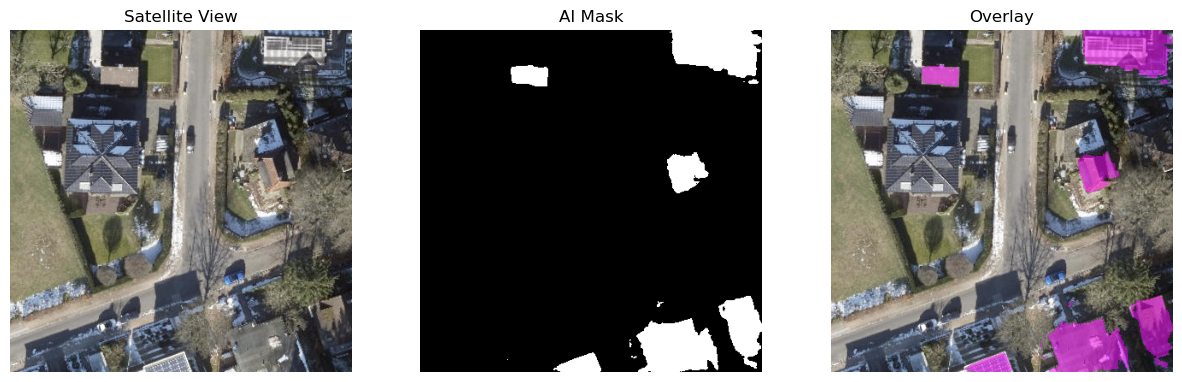

--- Processing: satellite_tile_1.png ---


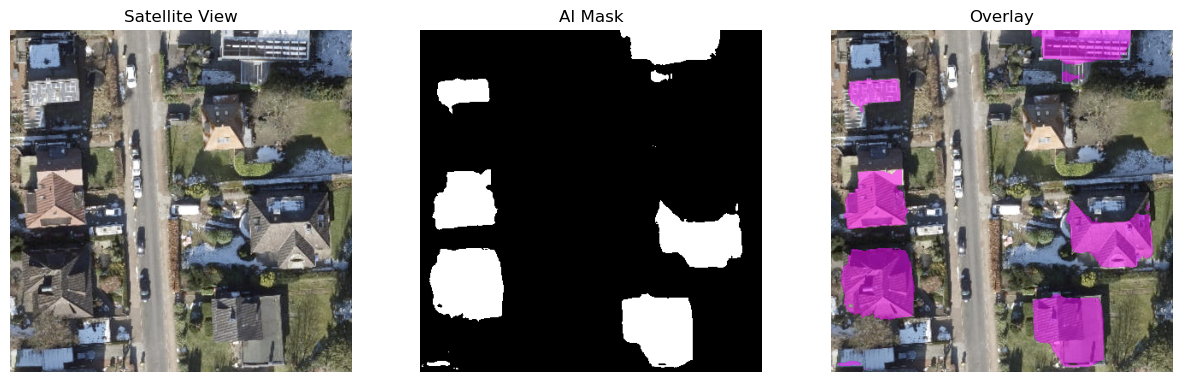

--- Processing: satellite_tile_2.png ---


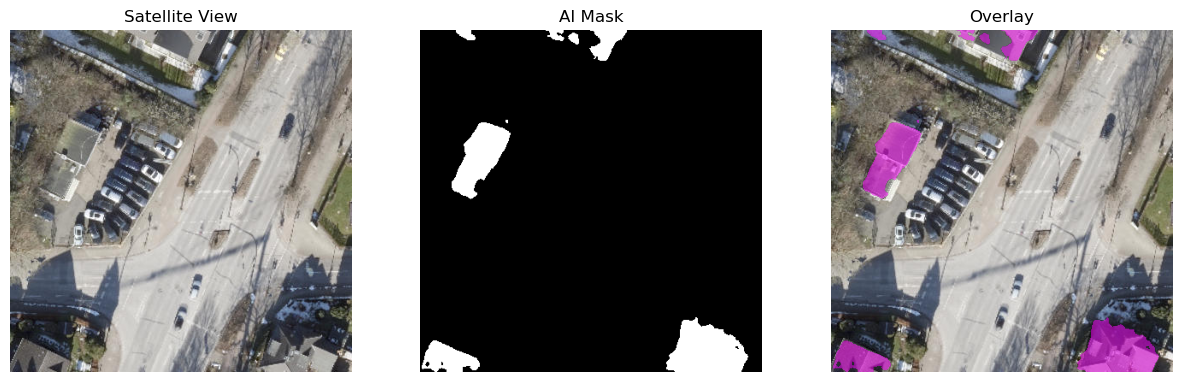

--- Processing: satellite_tile_3.png ---


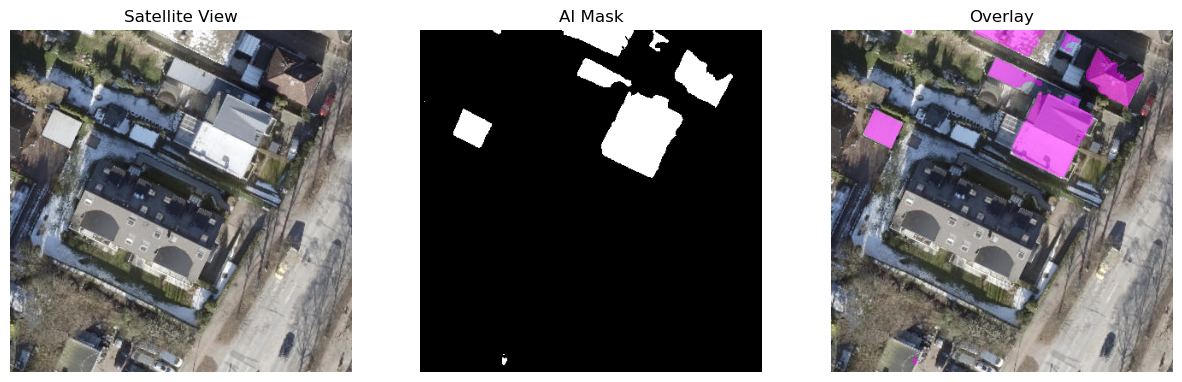

In [34]:
import os
from glob import glob

# 1. We know this works now based on your output
model_path = "../models/final_refined_roof_model.pth"

# 2. Point to the data folder one level up
image_folder = "../data/images" 

if os.path.exists(image_folder):
    image_files = sorted([f for f in os.listdir(image_folder) if f.endswith(('.jpg', '.png'))])
    print(f"✅ Found {len(image_files)} images. Starting Visualization...")
    
    for img_name in image_files:
        full_img_path = os.path.join(image_folder, img_name)
        print(f"--- Processing: {img_name} ---")
        visualize_solar_results(full_img_path, model_path)
else:
    # If it's still not found, let's list the parent directory to see where 'data' went
    parent_dir = os.listdir('..')
    print(f"❌ Still can't find 'data/images'. Here is what is in your parent folder: {parent_dir}")